# Assignment 12: EDA 2
##### Author: Md Ashhar Farooqui
##### Date: 19-07-2025

## 1. Data Exploration and Preprocessing
1.1 Load the Dataset and Basic Exploration

In [74]:
import pandas as pd

# Load the dataset (update the path if needed)
df = pd.read_csv('adult_with_headers.csv')

In [75]:
# Basic exploration
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education_num   32561 non-null  int64 
 5   marital_status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital_gain    32561 non-null  int64 
 11  capital_loss    32561 non-null  int64 
 12  hours_per_week  32561 non-null  int64 
 13  native_country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [77]:
df.describe()

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


### 1.2 Handle Missing Values

In [78]:
# If missing values are represented as '?', replace them with np.nan
df.replace('?', pd.NA, inplace=True)

In [79]:
# Check again for missing values
print(df.isnull().sum())

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64


### 1.3 Scaling Numerical Features

In [80]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Identify numerical columns
num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns

# Standard Scaling
scaler_std = StandardScaler()
df_std = df_clean.copy()
df_std[num_cols] = scaler_std.fit_transform(df_std[num_cols])

# Min-Max Scaling
scaler_mm = MinMaxScaler()
df_mm = df_clean.copy()
df_mm[num_cols] = scaler_mm.fit_transform(df_mm[num_cols])

## 2. Encoding Techniques

In [81]:
from sklearn.preprocessing import LabelEncoder

cat_cols = df_clean.select_dtypes(include=['object']).columns

# One-Hot Encoding for <5 categories, Label Encoding otherwise
df_encoded = df_clean.copy()
for col in cat_cols:
    if df_encoded[col].nunique() < 5:
        df_encoded = pd.get_dummies(df_encoded, columns=[col], prefix=col)
    else:
        le = LabelEncoder()
        df_encoded[col] = le.fit_transform(df_encoded[col])

## 3. Feature Engineering
### 3.1 Create New Features

In [82]:
# Example 1: Age buckets
df_encoded['age_bucket'] = pd.cut(df_encoded['age'], bins=[0, 25, 45, 65, 100], labels=['Young', 'Adult', 'Senior', 'Elderly'])

# Example 2: Working hours category
df_encoded['hours_per_week_cat'] = pd.cut(df_encoded['hours_per_week'], bins=[0, 20, 40, 60, 100], labels=['Part-time', 'Full-time', 'Overtime', 'Extreme'])

# Rationale: Age and working hours may have non-linear effects on income.

### 3.2 Log Transformation for Skewed Feature

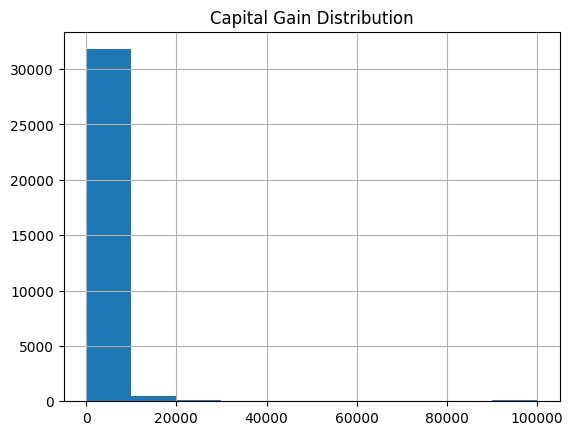

In [83]:
import numpy as np
import matplotlib.pyplot as plt

# Check skewness
df_encoded['capital_gain'].hist()
plt.title('Capital Gain Distribution')
plt.show()

# Apply log transformation
df_encoded['capital_gain_log'] = np.log1p(df_encoded['capital_gain'])

## 4. Feature Selection
### 4.1 Isolation Forest for Outlier Removal

In [88]:
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
outliers = iso.fit_predict(df_encoded[num_cols])
df_no_outliers = df_encoded[outliers == 1]
df_no_outliers

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,capital_gain,capital_loss,hours_per_week,native_country,sex_ Female,sex_ Male,income_ <=50K,income_ >50K,age_bucket,hours_per_week_cat,capital_gain_log
0,39,7,77516,9,13,4,1,1,4,2174,0,40,39,False,True,True,False,Adult,Full-time,7.684784
1,50,6,83311,9,13,2,4,0,4,0,0,13,39,False,True,True,False,Senior,Part-time,0.000000
2,38,4,215646,11,9,0,6,1,4,0,0,40,39,False,True,True,False,Adult,Full-time,0.000000
3,53,4,234721,1,7,2,6,0,2,0,0,40,39,False,True,True,False,Senior,Full-time,0.000000
4,28,4,338409,9,13,2,10,5,2,0,0,40,5,True,False,True,False,Adult,Full-time,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,38,39,True,False,True,False,Adult,Full-time,0.000000
32557,40,4,154374,11,9,2,7,0,4,0,0,40,39,False,True,False,True,Adult,Full-time,0.000000
32558,58,4,151910,11,9,6,1,4,4,0,0,40,39,True,False,True,False,Senior,Full-time,0.000000
32559,22,4,201490,11,9,4,1,3,4,0,0,20,39,False,True,True,False,Young,Part-time,0.000000


### 4.2 PPS (Predictive Power Score) Analysis

In [85]:
# Install ppscore if not already installed
# !pip install ppscore

import ppscore as pps

# PPS matrix
pps_matrix = pps.matrix(df_no_outliers)
print(pps_matrix[['x', 'y', 'ppscore']].sort_values(by='ppscore', ascending=False).head(10))

                    x                 y  ppscore
17                age        age_bucket      1.0
399  capital_gain_log  capital_gain_log      1.0
315     income_ <=50K     income_ <=50K      1.0
336      income_ >50K      income_ >50K      1.0
357        age_bucket        age_bucket      1.0
21          workclass         workclass      1.0
335      income_ >50K     income_ <=50K      1.0
252    native_country    native_country      1.0
273       sex_ Female       sex_ Female      1.0
274       sex_ Female         sex_ Male      1.0


In [86]:
# Remove non-numeric columns 'age_bucket' and 'hours_per_week_cat' before calculating correlation
df_numeric = df_no_outliers.drop(columns=['age_bucket', 'hours_per_week_cat'])
print(df_numeric)

       age  workclass  fnlwgt  education  education_num  marital_status  \
0       39          7   77516          9             13               4   
1       50          6   83311          9             13               2   
2       38          4  215646         11              9               0   
3       53          4  234721          1              7               2   
4       28          4  338409          9             13               2   
...    ...        ...     ...        ...            ...             ...   
32556   27          4  257302          7             12               2   
32557   40          4  154374         11              9               2   
32558   58          4  151910         11              9               6   
32559   22          4  201490         11              9               4   
32560   52          5  287927         11              9               2   

       occupation  relationship  race  capital_gain  capital_loss  \
0               1             

In [87]:
# Correlation matrix
print(df_numeric.corr())

                       age  workclass    fnlwgt  education  education_num  \
age               1.000000   0.003213 -0.077302  -0.010313       0.031440   
workclass         0.003213   1.000000 -0.018212   0.022219       0.048952   
fnlwgt           -0.077302  -0.018212  1.000000  -0.028766      -0.043846   
education        -0.010313   0.022219 -0.028766   1.000000       0.357776   
education_num     0.031440   0.048952 -0.043846   0.357776       1.000000   
marital_status   -0.270851  -0.063616  0.028712  -0.037835      -0.066341   
occupation       -0.021116   0.252917  0.000535  -0.022416       0.108103   
relationship     -0.263144  -0.090675  0.009003  -0.009715      -0.091079   
race              0.027157   0.049600 -0.021598   0.014726       0.030788   
capital_gain      0.108184   0.029188 -0.008207   0.029125       0.141995   
capital_loss      0.040729   0.008622 -0.013248   0.019229       0.078918   
hours_per_week    0.071138   0.138228 -0.021618   0.054525       0.144119   